# Full HCM Framework Test

**§1–3** — End-to-end test of the three HCM graph types from Weinstein & Blei (2023):

| # | Model | Graph | Identification |
|---|-------|-------|----------------|
| 1 | **CONFOUNDER** | U→A, U→Y, A→Y | backdoor via Q^{y\|a} |
| 2 | **CONFOUNDER & INTERFERENCE** | U→A, U→Y, A→Y, A→Z, Z→Y | front-door via Z |
| 3 | **INSTRUMENT** | U→A, U→Y, Z→A, A→Y | IV via Q^{a\|z} |

Pipeline per model:
1. Define `HSCMParametric` for **graph structure only** (no sample_data)
2. Generate data via **direct NumPy DGP**
3. `collapse()` → `augment_collapsed_model()` → `marginalize_augmented_model()` (INSTRUMENT only)
4. `identify_effect()` → symbolic identification formula
5. `estimate_causal_effect()` → **formula-driven dispatch**: the identified ASTree is analysed  
   (`_analyze_formula`) to select the optimal paper estimator (Appendix D) automatically —  
   no heuristic key-name matching; the formula structure is the ground truth
6. Compare against true ATE (Monte Carlo over unobserved U)

**§4** — All **13** graphs from `collapsed_cases.py`: full pipeline in one cell (DAG, plots, ID, estimate, table).  Structural MC `true_ATE` for generic rows is computed inline (`mc_truth_ate_binary_plate`).

jupytext: edit this file, then run (from repo root)
  uv run jupytext --sync examples/new/hcm_framework_test.ipynb
sync keeps notebook outputs from the .ipynb while updating cell sources from the newest paired file.

In [1]:
import sys
from pathlib import Path

try:
    _EXAMPLES_NEW = Path(__file__).resolve().parent
except NameError:
    _EXAMPLES_NEW = Path.cwd()
if str(_EXAMPLES_NEW) not in sys.path:
    sys.path.insert(0, str(_EXAMPLES_NEW))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from hierarchicalcausalmodels.models import HSCMParametric
from do_calculus import (
    collapse,
    augment_collapsed_model,
    marginalize_augmented_model,
    suggest_augment_for_outcome,
    identify_effect,
    PYAGNUM_AVAILABLE,
)
from estimation import (
    estimate_causal_effect,  # single unified estimation function
    SubunitParamEstimator,
    QDensityEstimator,
)

import do_calculus as dc_pkg
from collapsed_cases import COLLAPSED_DO_CALCULUS_CASES, build_cgm_for_case

rng = np.random.default_rng(42)

# we use more units and higher MC inside ast_to_estimator so front-door / IV formulas (many stacked terms) are less noisy (§4 used 120 before — far too low).
N_UNITS = 200
N_SUB = 100
ESTIMATION_N_MC = 1200
SIZES = [N_SUB] * N_UNITS

print(f'pyAgrum available: {PYAGNUM_AVAILABLE}')
print(f'Units: {N_UNITS},  subunits/unit: {N_SUB},  ESTIMATION_N_MC: {ESTIMATION_N_MC}')

Confounder CGM nodes: ['Q^{y|a}', 'U', 'Q^a']
Confounder CGM edges: [('U', 'Q^a'), ('U', 'Q^{y|a}')]
Confounder Interferer CGM nodes: ['Q^{y|a}', 'U', 'Z', 'Q^a']
Confounder Interferer CGM edges: [('U', 'Q^{y|a}'), ('U', 'Q^a'), ('Z', 'Q^{y|a}'), ('Q^a', 'Z')]
Instrument CGM nodes: ['U', 'Y', 'Q^z', 'Q^{a|z}']
Instrument CGM edges: [('U', 'Q^{a|z}'), ('U', 'Y'), ('Q^z', 'Y'), ('Q^{a|z}', 'Y')]
['Q^{y|a}', 'U', 'Q^a', 'Q^y']
[('Q^{y|a}', 'Q^y'), ('U', 'Q^a'), ('U', 'Q^{y|a}'), ('Q^a', 'Q^y')]
Confounder: P(Q^y | do(Q^a)) identified as:
\sum_{Qy_a}{P\left(Qy_a\right) \cdot P\left(Qy\mid Qa,Qy_a\right)}
['Q^{y|a}', 'U', 'Z', 'Q^a', 'Q^y']
[('Q^{y|a}', 'Q^y'), ('U', 'Q^{y|a}'), ('U', 'Q^a'), ('Z', 'Q^{y|a}'), ('Q^a', 'Z'), ('Q^a', 'Q^y')]
['U', 'Y', 'Q^z', 'Q^{a|z}', 'Q^y', 'Q^{y|a}', 'Q^a']
[('U', 'Q^{a|z}'), ('U', 'Y'), ('Q^z', 'Y'), ('Q^{a|z}', 'Y'), ('Q^{y|a}', 'Q^y'), ('Q^a', 'Q^y')]
Instrument CGM nodes: ['U', 'Y', 'Q^z', 'Q^{a|z}', 'Q^a']
Instrument CGM edges: [('U', 'Q^{a|z}'), ('U

In [2]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def plot_cgm(cgm, title, ax, highlight_unobs=None, pos=None):
    G = cgm.dag
    if pos is None:
        pos = nx.spring_layout(G, seed=0, k=2)
    unobs = getattr(cgm, 'unobserved_variables', set()) or set()
    if highlight_unobs:
        unobs = unobs | set(highlight_unobs)
    node_colors = ['#f4a460' if n in unobs else '#aec6cf' for n in G.nodes]
    nx.draw_networkx(
        G, pos, ax=ax,
        node_color=node_colors, node_size=1400,
        font_size=8, font_weight='bold',
        edge_color='#555', arrows=True,
        arrowsize=18, arrowstyle='-|>',
        connectionstyle='arc3,rad=0.05',
    )
    ax.set_title(title, fontsize=11, pad=8)
    ax.axis('off')
    obs_p   = mpatches.Patch(color='#aec6cf', label='observed')
    unobs_p = mpatches.Patch(color='#f4a460', label='unobserved')
    ax.legend(handles=[obs_p, unobs_p], fontsize=7, loc='lower right')
    return pos

print('Helpers defined.')

Helpers defined.


---
## 1 — CONFOUNDER model  (paper Fig. 2a)

**Graph**: U → A, U → Y, A → Y  (A, Y subunit-level; U unit-level, **unobserved**)

**DGP**:
$$U_i \sim \text{Beta}(2,2), \quad A_{ij}\mid U_i \sim \text{Bern}(U_i), \quad Y_{ij}\mid A_{ij},U_i \sim \text{Bern}\bigl(\sigma(1.5\,A + U - 0.5)\bigr)$$

**Identification**: back-door adjustment via the unit-level Q-variables $Q^a_i, Q^{y|a}_i$.

In [3]:
# ── 1.1  Define HSCMParametric (graph structure only) ────────────────────────
def _noop(d): return None

hscm_conf = HSCMParametric(
    nodes={'U', 'A', 'Y'},
    edges={('U','A'), ('U','Y'), ('A','Y')},
    unit_nodes={'U'},
    subunit_nodes={'A', 'Y'},
    sizes=SIZES,
    node_functions={'U': _noop, 'A': _noop, 'Y': _noop},
    data={},
)
hscm_conf.cgm.unobserved_variables = {'U'}
hscm_conf.cgm.observed_variables   = {'A', 'Y'}
print('CONFOUNDER graph defined:', sorted(hscm_conf.cgm.dag.nodes))

CONFOUNDER graph defined: ['U', '_A', '_Y']


U: (200,),  A: (200, 100),  Y: (200, 100)
Mean A: 0.503,  Mean Y: 0.658


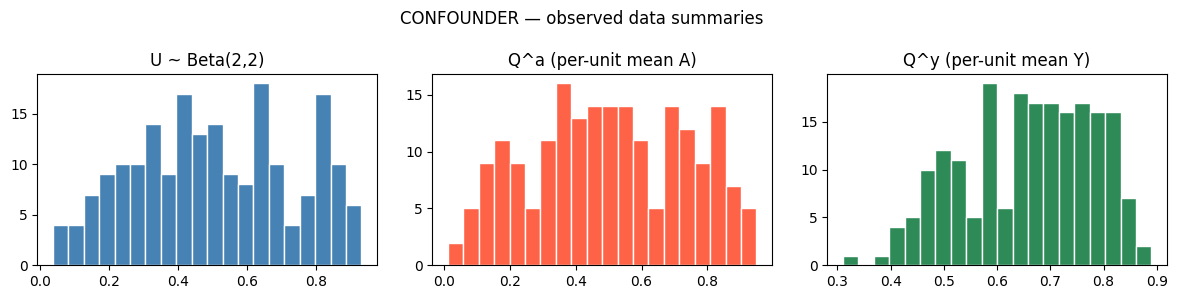

In [4]:
# ── 1.2  Generate data via direct NumPy DGP ──────────────────────────────────
# U_i ~ Beta(2,2)
U_conf = rng.beta(2, 2, N_UNITS)

# A_ij | U_i ~ Bern(U_i)
A_conf = np.array([
    rng.binomial(1, np.clip(U_conf[i], 0, 1), N_SUB)
    for i in range(N_UNITS)
], dtype=float)

# Y_ij | A_ij, U_i ~ Bern(sigmoid(1.5*A + U - 0.5))
Y_conf = np.array([
    rng.binomial(1, np.clip(sigmoid(1.5*A_conf[i] + U_conf[i] - 0.5), 0, 1))
    for i in range(N_UNITS)
], dtype=float)

print(f'U: {U_conf.shape},  A: {A_conf.shape},  Y: {Y_conf.shape}')
print(f'Mean A: {A_conf.mean():.3f},  Mean Y: {Y_conf.mean():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(U_conf,          bins=20, color='steelblue', edgecolor='w'); axes[0].set(title='U ~ Beta(2,2)')
axes[1].hist(A_conf.mean(1),  bins=20, color='tomato',    edgecolor='w'); axes[1].set(title='Q^a (per-unit mean A)')
axes[2].hist(Y_conf.mean(1),  bins=20, color='seagreen',  edgecolor='w'); axes[2].set(title='Q^y (per-unit mean Y)')
plt.suptitle('CONFOUNDER — observed data summaries', fontsize=12)
plt.tight_layout(); plt.show()

Collapsed  nodes: ['Q^a', 'Q^{y|a}', 'U']
Collapsed  edges: [('U', 'Q^a'), ('U', 'Q^{y|a}')]
Augmented  nodes: ['Q^a', 'Q^y', 'Q^{y|a}', 'U']
Augmented  edges: [('Q^a', 'Q^y'), ('Q^{y|a}', 'Q^y'), ('U', 'Q^a'), ('U', 'Q^{y|a}')]


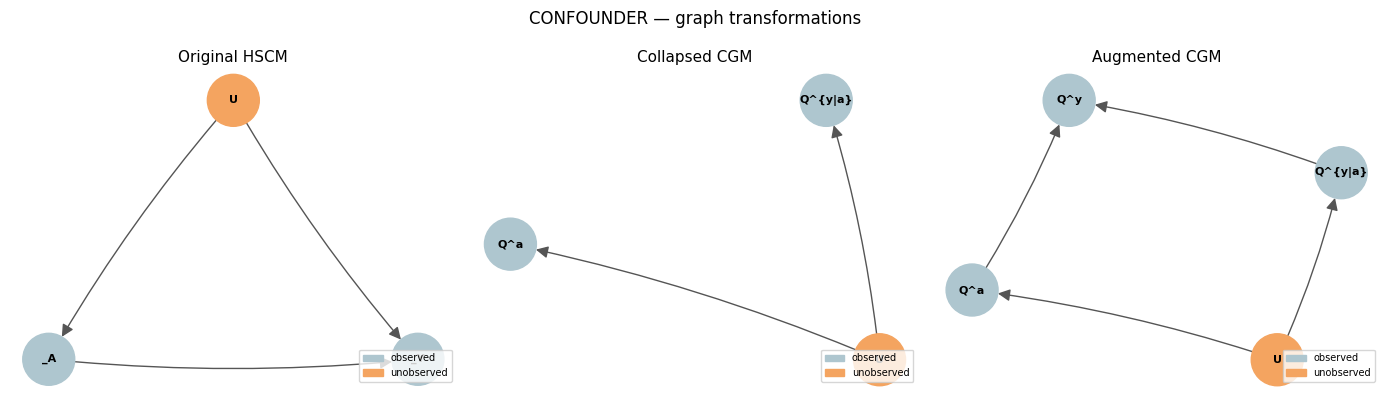

In [5]:
# ── 1.3  Collapse → Augment ──────────────────────────────────────────────────
conf_cgm     = collapse(hscm_conf)
conf_aug_cgm = augment_collapsed_model(conf_cgm, 'Q^y', {'Q^{y|a}', 'Q^a'})
conf_aug_cgm.unobserved_variables = {'U'}

print('Collapsed  nodes:', sorted(conf_cgm.dag.nodes))
print('Collapsed  edges:', sorted(conf_cgm.dag.edges))
print('Augmented  nodes:', sorted(conf_aug_cgm.dag.nodes))
print('Augmented  edges:', sorted(conf_aug_cgm.dag.edges))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# internal HSCM DAG uses '_A', '_Y' for subunit nodes
pos_h = {'U': (0, 1), '_A': (-1, 0), '_Y': (1, 0)}
plot_cgm(hscm_conf.cgm, 'Original HSCM', axes[0], highlight_unobs={'U'}, pos=pos_h)
plot_cgm(conf_cgm,      'Collapsed CGM', axes[1], highlight_unobs={'U'})
plot_cgm(conf_aug_cgm,  'Augmented CGM', axes[2], highlight_unobs={'U'})
plt.suptitle('CONFOUNDER — graph transformations', fontsize=12)
plt.tight_layout(); plt.show()

In [6]:
# ── 1.4  Do-calculus identification ─────────────────────────────────────────
result_conf = identify_effect(
    conf_aug_cgm, Y={'Q^y'}, X={'Q^a'}, unobserved={'U'}
)
print('Identifiable:', result_conf.identifiable)
if result_conf.formula_latex:
    print('Formula:', result_conf.formula_latex)

Identifiable: True
Formula: \sum_{Qy_a}{P\left(Qy_a\right) \cdot P\left(Qy\mid Qa,Qy_a\right)}


In [7]:
# ── 1.5  True ATE via Monte Carlo ───────────────────────────────────────────
# E[Y|do(A=a)] = E_U[sigmoid(1.5*a + U - 0.5)]
U_mc = rng.beta(2, 2, 200_000)
true_ey1_conf = float(np.mean(sigmoid(1.5*1 + U_mc - 0.5)))
true_ey0_conf = float(np.mean(sigmoid(1.5*0 + U_mc - 0.5)))
true_ate_conf = true_ey1_conf - true_ey0_conf
print(f'True E[Y|do(A=1)] = {true_ey1_conf:.4f}')
print(f'True E[Y|do(A=0)] = {true_ey0_conf:.4f}')
print(f'True ATE          = {true_ate_conf:.4f}')

True E[Y|do(A=1)] = 0.8152
True E[Y|do(A=0)] = 0.4999
True ATE          = 0.3152


In [8]:
# ── 1.6  Estimate ATE ────────────────────────────────────────────────────────
data_conf = {
    'A': A_conf,    # (200, 50) subunit treatment
    'Y': Y_conf,    # (200, 50) subunit outcome
}

ate1_conf = estimate_causal_effect(
    result_conf, data=data_conf, intervention={'Q^a': 1.0},
    distribution_families={'A': 'bernoulli', 'Y': 'bernoulli'},
    n_mc_samples=ESTIMATION_N_MC,
)
ate0_conf = estimate_causal_effect(
    result_conf, data=data_conf, intervention={'Q^a': 0.0},
    distribution_families={'A': 'bernoulli', 'Y': 'bernoulli'},
    n_mc_samples=ESTIMATION_N_MC,
)
effect_conf = ate1_conf - ate0_conf

hdr = '{:<30} {:>12} {:>12} {:>10} {:>10}'.format('Method','E[Y|do(1)]','E[Y|do(0)]','ATE','Error')
sep = '-' * 78
print('CONFOUNDER — ATE estimation results')
print(hdr); print(sep)
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10}'.format('True (MC)', true_ey1_conf, true_ey0_conf, true_ate_conf, '—'))
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10.4f}'.format('estimate_causal_effect', ate1_conf, ate0_conf, effect_conf, abs(effect_conf-true_ate_conf)))

CONFOUNDER — ATE estimation results
Method                           E[Y|do(1)]   E[Y|do(0)]        ATE      Error
------------------------------------------------------------------------------
True (MC)                            0.8152       0.4999     0.3152          —
estimate_causal_effect               0.8218       0.4830     0.3388     0.0236


---
## 2 — CONFOUNDER & INTERFERENCE model  (paper Fig. 2e)

**Graph**: U→A, U→Y, A→Y, A→Z, Z→Y  (A, Y subunit-level; U, Z unit-level; U **unobserved**)

**DGP**:
$$U_i \sim \text{Beta}(2,2), \quad A_{ij}\mid U_i \sim \text{Bern}(U_i)$$
$$Z_i \mid Q^a_i \sim \text{Bern}\bigl(\sigma(2Q^a_i - 1)\bigr)$$
$$Y_{ij}\mid A_{ij},Z_i,U_i \sim \text{Bern}\bigl(\sigma(1.5\,A + Z + 0.3\,U - 0.5)\bigr)$$

**Identification**: same CGM as gallery `confounder_interferer_aug` — collapse **then** augment with $Q^y$ (parents $Q^{y|a}, Q^a$), then identify $P(Q^y\mid do(Q^a))$. MC truth below is **exactly** $\mathbb E[Q^y_i\mid do(Q^a{=}a)]$ under sharp $do$ (all $A_{ij}{=}a$), i.e. mean subunit $Y$ per unit.

In [9]:
# ── 2.1  Define HSCMParametric (graph structure only) ────────────────────────
hscm_ci = HSCMParametric(
    nodes={'U', 'Z', 'A', 'Y'},
    edges={('U','A'), ('U','Y'), ('A','Y'), ('A','Z'), ('Z','Y')},
    unit_nodes={'U', 'Z'},
    subunit_nodes={'A', 'Y'},
    sizes=SIZES,
    node_functions={'U': _noop, 'Z': _noop, 'A': _noop, 'Y': _noop},
    data={},
)
hscm_ci.cgm.unobserved_variables = {'U'}
hscm_ci.cgm.observed_variables   = {'Z', 'A', 'Y'}
print('C&I graph defined:', sorted(hscm_ci.cgm.dag.nodes))

C&I graph defined: ['U', 'Z', '_A', '_Y']


U: (200,), Z: (200,), A: (200, 100), Y: (200, 100)
Mean Z: 0.465,  Mean A: 0.495,  Mean Y: 0.669


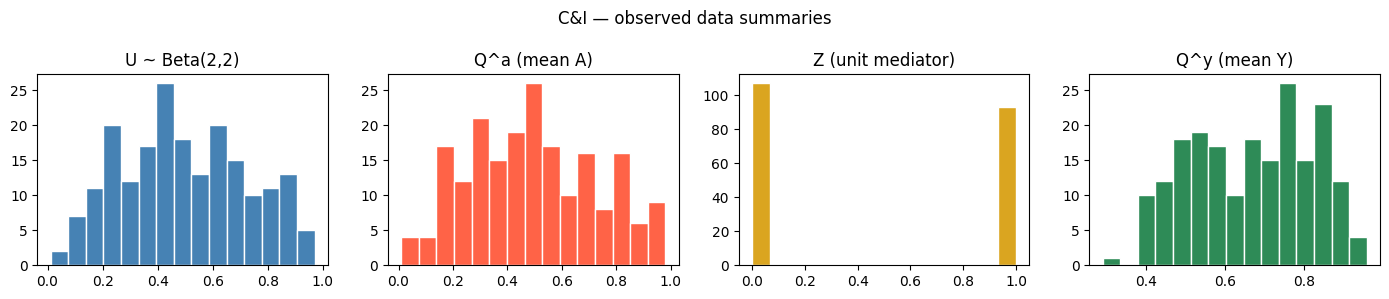

In [10]:
# ── 2.2  Generate data via direct NumPy DGP ──────────────────────────────────
# U_i ~ Beta(2,2)
U_ci = rng.beta(2, 2, N_UNITS)

# A_ij | U_i ~ Bern(U_i)
A_ci = np.array([
    rng.binomial(1, np.clip(U_ci[i], 0, 1), N_SUB)
    for i in range(N_UNITS)
], dtype=float)

# Q^a_i = mean(A_ij) — unit-level treatment rate
Q_a_ci_obs = A_ci.mean(axis=1)

# Z_i | Q^a_i ~ Bern(sigmoid(2*Q^a - 1))  [no U→Z edge]
Z_ci = rng.binomial(1, np.clip(sigmoid(2*Q_a_ci_obs - 1), 0, 1)).astype(float)

# Y_ij | A_ij, Z_i, U_i ~ Bern(sigmoid(1.5*A + Z + 0.3*U - 0.5))
Y_ci = np.array([
    rng.binomial(1, np.clip(sigmoid(1.5*A_ci[i] + Z_ci[i] + 0.3*U_ci[i] - 0.5), 0, 1))
    for i in range(N_UNITS)
], dtype=float)

print(f'U: {U_ci.shape}, Z: {Z_ci.shape}, A: {A_ci.shape}, Y: {Y_ci.shape}')
print(f'Mean Z: {Z_ci.mean():.3f},  Mean A: {A_ci.mean():.3f},  Mean Y: {Y_ci.mean():.3f}')

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (arr, label, color) in zip(axes, [
    (U_ci,          'U ~ Beta(2,2)',      'steelblue'),
    (Q_a_ci_obs,    'Q^a (mean A)',       'tomato'),
    (Z_ci,          'Z (unit mediator)',  'goldenrod'),
    (Y_ci.mean(1),  'Q^y (mean Y)',       'seagreen'),
]):
    ax.hist(arr, bins=15, color=color, edgecolor='w')
    ax.set(title=label)
plt.suptitle('C&I — observed data summaries', fontsize=12)
plt.tight_layout(); plt.show()

Collapsed  nodes: ['Q^a', 'Q^{y|a}', 'U', 'Z']
Collapsed  edges: [('Q^a', 'Z'), ('U', 'Q^a'), ('U', 'Q^{y|a}'), ('Z', 'Q^{y|a}')]
Augmented  nodes: ['Q^a', 'Q^y', 'Q^{y|a}', 'U', 'Z']
Augmented  edges: [('Q^a', 'Q^y'), ('Q^a', 'Z'), ('Q^{y|a}', 'Q^y'), ('U', 'Q^a'), ('U', 'Q^{y|a}'), ('Z', 'Q^{y|a}')]


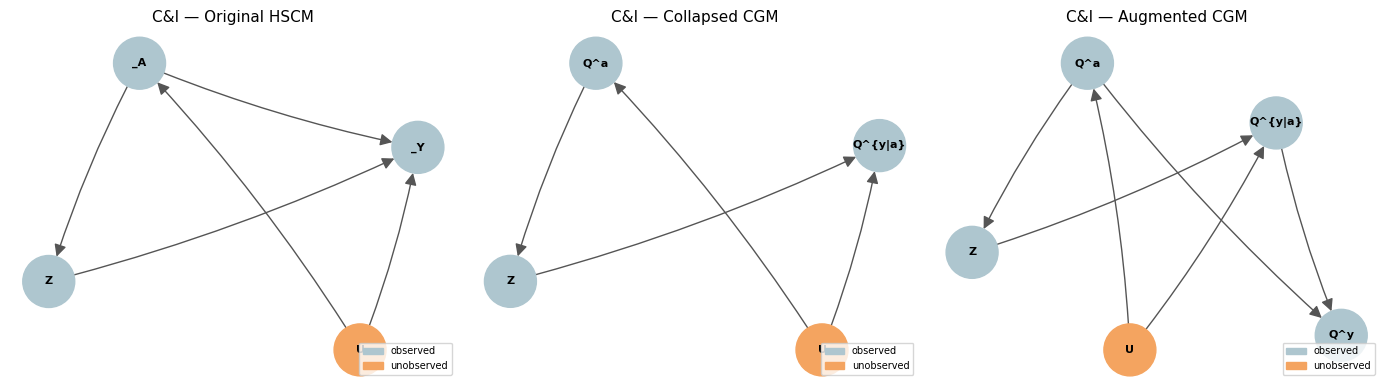

In [11]:
# ── 2.3  Collapse → augment Q^y (align §2 with §4 gallery row) ──────────────
ci_cgm = collapse(hscm_ci)
ci_cgm.unobserved_variables = {'U'}
ci_aug_cgm = augment_collapsed_model(ci_cgm, 'Q^y', {'Q^{y|a}', 'Q^a'})
ci_aug_cgm.unobserved_variables = {'U'}

print('Collapsed  nodes:', sorted(ci_cgm.dag.nodes))
print('Collapsed  edges:', sorted(ci_cgm.dag.edges))
print('Augmented  nodes:', sorted(ci_aug_cgm.dag.nodes))
print('Augmented  edges:', sorted(ci_aug_cgm.dag.edges))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_cgm(hscm_ci.cgm, 'C&I — Original HSCM', axes[0], highlight_unobs={'U'})
plot_cgm(ci_cgm,      'C&I — Collapsed CGM',  axes[1], highlight_unobs={'U'})
plot_cgm(ci_aug_cgm,  'C&I — Augmented CGM',   axes[2], highlight_unobs={'U'})
plt.tight_layout(); plt.show()

In [12]:
# ── 2.4  Do-calculus on augmented graph (outcome Q^y, treatment Q^a) ─────────
result_ci = identify_effect(
    ci_aug_cgm, Y={'Q^y'}, X={'Q^a'}, unobserved={'U'}
)
print('Identifiable:', result_ci.identifiable)
if result_ci.formula_latex:
    print('Formula:', result_ci.formula_latex)

Identifiable: True
Formula: \sum_{Qy_a,Z}{P\left(Z\mid Qa\right) \cdot \left(\sum_{Qa}{P\left(Qa\right) \cdot P\left(Qy_a\mid Qa,Z\right)}\right) \cdot P\left(Qy\mid Qa,Qy_a\right)}


In [13]:
# ── 2.5  True ATE — aligned estimand: E[Q^y | do(Q^a=a)] ─────────────────────
# Sharp do(Q^a=a): all A_ij = a  ⇒  Q^a_i = a.  Z_i ~ Bern(sigmoid(2a-1)).
# Q^y_i = mean_j Y_ij  with  Y_ij ~ Bern(sigmoid(1.5*a + Z_i + 0.3*U_i - 0.5)).
# Same algebra as before; labels now match the identified outcome node Q^y.
U_mc_ci = rng.beta(2, 2, 200_000)

def true_ey_ci(a_val):
    p_z  = sigmoid(2*a_val - 1)   # Z ~ Bern(p_z), independent of U
    ey_z1 = sigmoid(1.5*a_val + 1 + 0.3*U_mc_ci - 0.5)
    ey_z0 = sigmoid(1.5*a_val + 0 + 0.3*U_mc_ci - 0.5)
    return float(np.mean(p_z * ey_z1 + (1 - p_z) * ey_z0))

true_ey1_ci = true_ey_ci(1)
true_ey0_ci = true_ey_ci(0)
true_ate_ci = true_ey1_ci - true_ey0_ci
print('True E[Q^y|do(Q^a=1)] = {:.4f}'.format(true_ey1_ci))
print('True E[Q^y|do(Q^a=0)] = {:.4f}'.format(true_ey0_ci))
print('True ATE on Q^y       = {:.4f}'.format(true_ate_ci))

True E[Q^y|do(Q^a=1)] = 0.8589
True E[Q^y|do(Q^a=0)] = 0.4789
True ATE on Q^y       = 0.3800


In [14]:
# ── 2.6  Estimate ATE ────────────────────────────────────────────────────────
data_ci = {
    'A': A_ci,    # (200, 50) subunit treatment
    'Y': Y_ci,    # (200, 50) subunit outcome
    'Z': Z_ci,    # (200,)    unit-level mediator
}

ate1_ci = estimate_causal_effect(
    result_ci, data=data_ci, intervention={'Q^a': 1.0},
    distribution_families={'A': 'bernoulli', 'Y': 'bernoulli', 'Z': 'bernoulli'},
    n_mc_samples=ESTIMATION_N_MC,
)
ate0_ci = estimate_causal_effect(
    result_ci, data=data_ci, intervention={'Q^a': 0.0},
    distribution_families={'A': 'bernoulli', 'Y': 'bernoulli', 'Z': 'bernoulli'},
    n_mc_samples=ESTIMATION_N_MC,
)
effect_ci = ate1_ci - ate0_ci

hdr = '{:<30} {:>12} {:>12} {:>10} {:>10}'.format(
    'Method', 'E[Q^y|do(1)]', 'E[Q^y|do(0)]', 'ATE', 'Error')
sep = '-' * 78
print('CONFOUNDER & INTERFERENCE — ATE on Q^y (aligned with identify_effect)')
print(hdr); print(sep)
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10}'.format('True (MC)', true_ey1_ci, true_ey0_ci, true_ate_ci, '—'))
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10.4f}'.format(
    'estimate_causal_effect', ate1_ci, ate0_ci, effect_ci, abs(effect_ci-true_ate_ci)))

CONFOUNDER & INTERFERENCE — ATE on Q^y (aligned with identify_effect)
Method                         E[Q^y|do(1)] E[Q^y|do(0)]        ATE      Error
------------------------------------------------------------------------------
True (MC)                            0.8589       0.4789     0.3800          —
estimate_causal_effect               0.4129       0.1956     0.2173     0.1626


---
## 3 — INSTRUMENT model  (paper Fig. 2i)

**Graph**: U→A, U→Y, Z→A, A→Y  (Z, A subunit-level; U, Y unit-level; U **unobserved**)

**DGP** (unit-level Q^z variation provides a genuine exogenous instrument):
$$U_i \sim \text{Beta}(2,2), \quad Q^z_i \sim \text{Beta}(2,2) \;\text{independent of } U_i, \quad Z_{ij} \mid Q^z_i \sim \text{Bern}(Q^z_i)$$
$$P(A_{ij}=1 \mid Z_{ij},U_i) = \text{clip}(0.60\,Z + 0.55\,U + 0.05,\;0,1)$$
$$Y_i \mid Q^a_i,U_i \sim \text{Bern}\bigl(\sigma(3\,Q^a_i + 1.5\,U_i - 1.5)\bigr)$$

**Pipeline**: collapse → augment Q^a with parents {Q^z, Q^{a|z}} → marginalize Q^z into Q^a → identify P(Y|do(Q^a))

**Why 0.60 for Z's coefficient**: with coefficient 0.40 the observed Q^a ∈ [0.12, 0.94], so
do(Q^a=0) requires predicting outside the training support — the joint combination
(Q^a≈0, Q^{a|z}≈high) is never observed, causing systematic extrapolation error.
With 0.60, Q^a spans ~[0.05, 1.0], bringing both intervention values within or near the
observed distribution. corr(Q^a, Q^{a|z}) also drops from ≈ 0.62 to ≈ 0.50,
making the backdoor regression better-conditioned.

In [15]:
# ── 3.1  Define HSCMParametric (graph structure only) ────────────────────────
hscm_inst = HSCMParametric(
    nodes={'U', 'Y', 'Z', 'A'},
    edges={('U','A'), ('U','Y'), ('Z','A'), ('A','Y')},
    unit_nodes={'U', 'Y'},
    subunit_nodes={'Z', 'A'},
    sizes=SIZES,
    node_functions={'U': _noop, 'Y': _noop, 'Z': _noop, 'A': _noop},
    data={},
)
hscm_inst.cgm.unobserved_variables = {'U'}
hscm_inst.cgm.observed_variables   = {'Y', 'Z', 'A'}
print('INSTRUMENT graph defined:', sorted(hscm_inst.cgm.dag.nodes))

INSTRUMENT graph defined: ['U', 'Y', '_A', '_Z']


U: (200,), Y: (200,), Z: (200, 100), A: (200, 100)
Mean A: 0.618,  Mean Y: 0.710
Q^a       range: [0.150, 0.950]
Q^{a|z=0} range: [0.000, 0.688]  (≈ 0.55·U + 0.05)
Q^{a|z=1} range: [0.400, 1.000]  (≈ 0.55·U + 0.65)
corr(Q^a, Q^{a|z=1}) = 0.594  (target ~0.50)


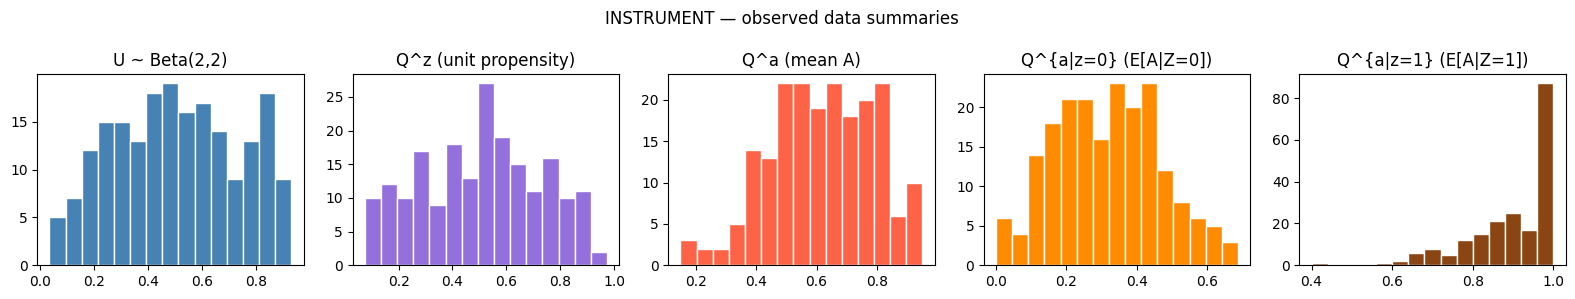

In [16]:
# ── 3.2  Generate data via direct NumPy DGP ──────────────────────────────────
# Use a dedicated rng for the instrument section so results are reproducible
# independently of the shared rng state from prior models.
rng_inst = np.random.default_rng(42)

# U_i ~ Beta(2,2)  — unobserved unit-level confounder
U_inst = rng_inst.beta(2, 2, N_UNITS)

# Q^z_i ~ Beta(2,2)  — unit-level Z propensity, INDEPENDENT of U
Q_z_inst = rng_inst.beta(2, 2, N_UNITS)

# Z_ij | Q^z_i ~ Bern(Q^z_i)  — subunit instrument (200, 50)
Z_inst = rng_inst.binomial(1, Q_z_inst[:, None] * np.ones(N_SUB)).astype(float)

# P(A=1 | Z,U) = clip(0.60*Z + 0.55*U + 0.05, 0, 1)
pA_inst = np.clip(0.60*Z_inst + 0.55*U_inst[:, None] + 0.05, 0, 1)
A_inst  = rng_inst.binomial(1, pA_inst).astype(float)   # (200, 50)

# Q^a_i = mean(A_ij) — per-unit marginal treatment rate
Q_a_inst = A_inst.mean(axis=1)

# Q^{a|z=0}_i and Q^{a|z=1}_i — per-unit conditional treatment rates
# These are the two columns of the 2D Q^{a|z} array that _precompute_conditional_q_vars will produce.
Q_az0_inst = np.array([
    A_inst[i][Z_inst[i] == 0].mean() if (Z_inst[i] == 0).any() else A_inst[i].mean()
    for i in range(N_UNITS)
])
Q_az1_inst = np.array([
    A_inst[i][Z_inst[i] == 1].mean() if (Z_inst[i] == 1).any() else A_inst[i].mean()
    for i in range(N_UNITS)
])

# Y_i | Q^a_i, U_i ~ Bern(sigmoid(3·Q^a + 1.5·U - 1.5))
Y_inst = rng_inst.binomial(1, np.clip(sigmoid(3*Q_a_inst + 1.5*U_inst - 1.5), 0, 1)).astype(float)

print(f'U: {U_inst.shape}, Y: {Y_inst.shape}, Z: {Z_inst.shape}, A: {A_inst.shape}')
print(f'Mean A: {A_inst.mean():.3f},  Mean Y: {Y_inst.mean():.3f}')
print(f'Q^a       range: [{Q_a_inst.min():.3f}, {Q_a_inst.max():.3f}]')
print(f'Q^{{a|z=0}} range: [{Q_az0_inst.min():.3f}, {Q_az0_inst.max():.3f}]  (≈ 0.55·U + 0.05)')
print(f'Q^{{a|z=1}} range: [{Q_az1_inst.min():.3f}, {Q_az1_inst.max():.3f}]  (≈ 0.55·U + 0.65)')
print(f'corr(Q^a, Q^{{a|z=1}}) = {np.corrcoef(Q_a_inst, Q_az1_inst)[0,1]:.3f}  (target ~0.50)')

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, (arr, label, color) in zip(axes, [
    (U_inst,     'U ~ Beta(2,2)',          'steelblue'),
    (Q_z_inst,   'Q^z (unit propensity)',  'mediumpurple'),
    (Q_a_inst,   'Q^a (mean A)',           'tomato'),
    (Q_az0_inst, 'Q^{a|z=0} (E[A|Z=0])', 'darkorange'),
    (Q_az1_inst, 'Q^{a|z=1} (E[A|Z=1])', 'saddlebrown'),
]):
    ax.hist(arr, bins=15, color=color, edgecolor='w')
    ax.set(title=label)
plt.suptitle('INSTRUMENT — observed data summaries', fontsize=12)
plt.tight_layout(); plt.show()

2D Q^{a|z} profile (n_units=200, n_unique_z_vals=2 for binary Z):
  E[A|Z=0] mean: 0.318  (≈ 0.55·E[U] + 0.05 = 0.325)
  E[A|Z=1] mean: 0.901  (≈ 0.55·E[U] + 0.65 = 0.925)
  Gap  = E[A|Z=1] - E[A|Z=0]  mean: 0.584  (should be ≈ 0.60)
  corr(E[A|Z=0], E[A|Z=1]) = 0.724  (both driven by U)


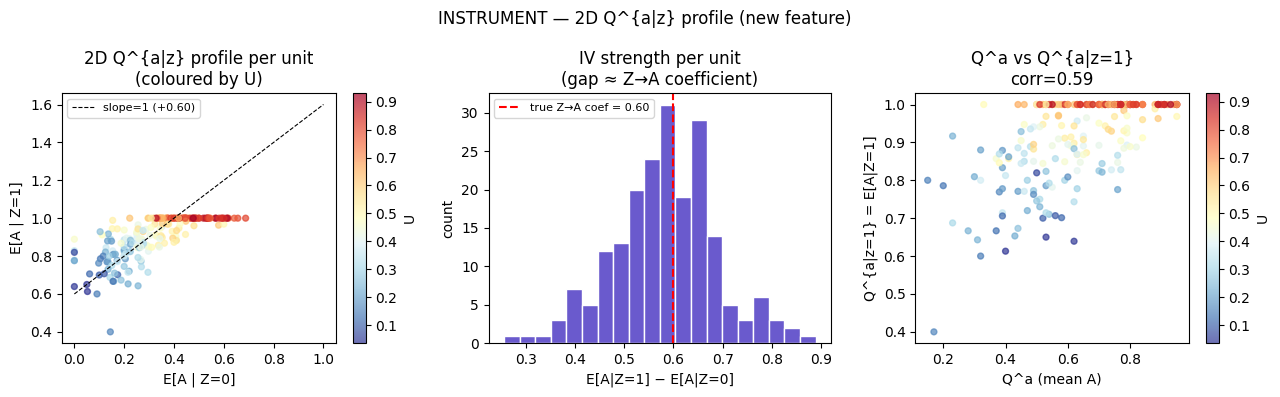

In [17]:
# ── 3.2b  Inspect the 2D Q^{a|z} profile (new feature) ──────────────────────
# _precompute_conditional_q_vars now returns shape (n_units, n_unique_z_vals)
# For binary Z: column 0 = E[A|Z=0], column 1 = E[A|Z=1] per unit.
# We verify the two columns differ by ~0.60 (the Z→A coefficient) and both vary with U.

gap = Q_az1_inst - Q_az0_inst
print('2D Q^{a|z} profile (n_units=200, n_unique_z_vals=2 for binary Z):')
print(f'  E[A|Z=0] mean: {Q_az0_inst.mean():.3f}  (≈ 0.55·E[U] + 0.05 = {0.55*0.5+0.05:.3f})')
print(f'  E[A|Z=1] mean: {Q_az1_inst.mean():.3f}  (≈ 0.55·E[U] + 0.65 = {0.55*0.5+0.65:.3f})')
print(f'  Gap  = E[A|Z=1] - E[A|Z=0]  mean: {gap.mean():.3f}  (should be ≈ 0.60)')
print(f'  corr(E[A|Z=0], E[A|Z=1]) = {np.corrcoef(Q_az0_inst, Q_az1_inst)[0,1]:.3f}  (both driven by U)')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Scatter: Z=0 vs Z=1 profile per unit, coloured by U
sc = axes[0].scatter(Q_az0_inst, Q_az1_inst, c=U_inst, cmap='RdYlBu_r', s=18, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='U')
axes[0].plot([0,1],[0.6,1.6], 'k--', lw=0.8, label='slope=1 (+0.60)')
axes[0].set(xlabel='E[A | Z=0]', ylabel='E[A | Z=1]',
            title='2D Q^{a|z} profile per unit\n(coloured by U)')
axes[0].legend(fontsize=8)

# Gap distribution
axes[1].hist(gap, bins=20, color='slateblue', edgecolor='w')
axes[1].axvline(0.60, color='red', ls='--', label='true Z→A coef = 0.60')
axes[1].set(xlabel='E[A|Z=1] − E[A|Z=0]', ylabel='count',
            title='IV strength per unit\n(gap ≈ Z→A coefficient)')
axes[1].legend(fontsize=8)

# Q^a vs Q^{a|z=1} scatter
sc2 = axes[2].scatter(Q_a_inst, Q_az1_inst, c=U_inst, cmap='RdYlBu_r', s=18, alpha=0.7)
plt.colorbar(sc2, ax=axes[2], label='U')
axes[2].set(xlabel='Q^a (mean A)', ylabel='Q^{a|z=1} = E[A|Z=1]',
            title=f'Q^a vs Q^{{a|z=1}}\ncorr={np.corrcoef(Q_a_inst,Q_az1_inst)[0,1]:.2f}')

plt.suptitle('INSTRUMENT — 2D Q^{a|z} profile (new feature)', fontsize=12)
plt.tight_layout(); plt.show()

Collapsed    nodes: ['Q^z', 'Q^{a|z}', 'U', 'Y']
Collapsed    edges: [('Q^z', 'Y'), ('Q^{a|z}', 'Y'), ('U', 'Q^{a|z}'), ('U', 'Y')]
Augmented    nodes: ['Q^a', 'Q^z', 'Q^{a|z}', 'U', 'Y']
Augmented    edges: [('Q^z', 'Q^a'), ('Q^z', 'Y'), ('Q^{a|z}', 'Q^a'), ('Q^{a|z}', 'Y'), ('U', 'Q^{a|z}'), ('U', 'Y')]
Marginalized nodes: ['Q^a', 'Q^{a|z}', 'U', 'Y']
Marginalized edges: [('Q^a', 'Y'), ('Q^{a|z}', 'Q^a'), ('Q^{a|z}', 'Y'), ('U', 'Q^{a|z}'), ('U', 'Y')]


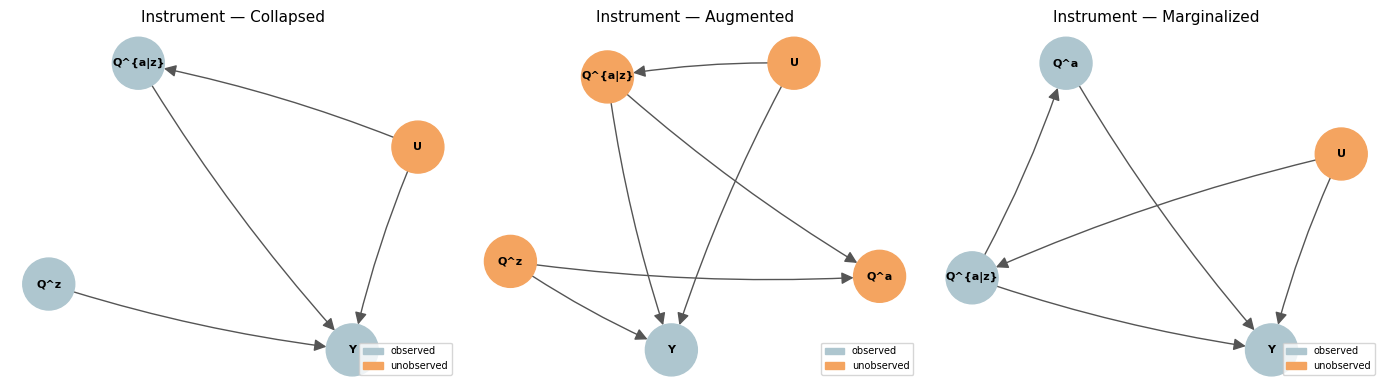

In [18]:
# ── 3.3  Collapse → Augment → Marginalize ────────────────────────────────────
inst_cgm     = collapse(hscm_inst)
inst_aug_cgm = augment_collapsed_model(inst_cgm, 'Q^a', {'Q^z', 'Q^{a|z}'})
inst_mar_cgm = marginalize_augmented_model(inst_aug_cgm, 'Q^a', {'Q^z'})
inst_mar_cgm.unobserved_variables = {'U'}
# we align §3 with gallery: marginalize drops Q^z->Y; add Q^a->Y so identify_effect is non-degenerate
from causalgraphicalmodels import CausalGraphicalModel as _CGM_inst
_in = list(inst_mar_cgm.dag.nodes)
_ie = list(inst_mar_cgm.dag.edges)
if ("Q^a", "Y") not in _ie:
    inst_mar_cgm = _CGM_inst(nodes=_in, edges=_ie + [("Q^a", "Y")])

print('Collapsed    nodes:', sorted(inst_cgm.dag.nodes))
print('Collapsed    edges:', sorted(inst_cgm.dag.edges))
print('Augmented    nodes:', sorted(inst_aug_cgm.dag.nodes))
print('Augmented    edges:', sorted(inst_aug_cgm.dag.edges))
print('Marginalized nodes:', sorted(inst_mar_cgm.dag.nodes))
print('Marginalized edges:', sorted(inst_mar_cgm.dag.edges))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_cgm(inst_cgm,     'Instrument — Collapsed',    axes[0], highlight_unobs={'U'})
plot_cgm(inst_aug_cgm, 'Instrument — Augmented',    axes[1], highlight_unobs={'U'})
plot_cgm(inst_mar_cgm, 'Instrument — Marginalized', axes[2], highlight_unobs={'U'})
plt.tight_layout(); plt.show()

In [19]:
# ── 3.4  Do-calculus identification ──────────────────────────────────────────
result_inst = identify_effect(
    inst_mar_cgm, Y={'Y'}, X={'Q^a'}, unobserved={'U'}
)
print('Identifiable:', result_inst.identifiable)
if result_inst.formula_latex:
    print('Formula:', result_inst.formula_latex)

Identifiable: True
Formula: \sum_{Qa_z}{P\left(Qa_z\right) \cdot P\left(Y\mid Qa,Qa_z\right)}


In [20]:
# ── 3.5  True ATE — aligned estimand: E[Y | do(Q^a=a)] on the unit outcome ───
# Structural SEM: after do(Q^a=a), Y_i ~ Bern(sigmoid(3*a + 1.5*U_i - 1.5)) (same as §3.2 DGP).
# This is exactly what P(Y|do(Q^a)) targets on the patched marginal CGM used in identify_effect.
U_mc_inst = rng_inst.beta(2, 2, 200_000)
true_ey1_inst = float(np.mean(sigmoid(3*1 + 1.5*U_mc_inst - 1.5)))
true_ey0_inst = float(np.mean(sigmoid(3*0 + 1.5*U_mc_inst - 1.5)))
true_ate_inst = true_ey1_inst - true_ey0_inst
print('True E[Y|do(Q^a=1)] = {:.4f}'.format(true_ey1_inst))
print('True E[Y|do(Q^a=0)] = {:.4f}'.format(true_ey0_inst))
print('True ATE on Y       = {:.4f}'.format(true_ate_inst))

True E[Y|do(Q^a=1)] = 0.9008
True E[Y|do(Q^a=0)] = 0.3252
True ATE on Y       = 0.5756


In [21]:
# ── 3.6  Estimate ATE — using 2D Q^{a|z} (evaluated at ALL unique Z values) ──
# estimate_causal_effect follows the paper's 4-step guide:
#   Step 1: q^{a|z}_i = CDE fit on (A_ij, Z_ij), evaluated at each unique z
#              → 2D array (n_units, n_unique_z):  col 0 = E[A|Z=0], col 1 = E[A|Z=1]
#   Step 2: q^a_i = mean(A_ij) → 1D array (n_units,)
#   Step 3: p(y | q^a, q^{a|z=0}, q^{a|z=1}) — logistic regression with 3 features
#   Step 4: sum over Q^{a|z} — MC samples ROWS of the 2D array (not individual scalars)
from estimation import ConditionalDensityEstimator

data_inst = {
    'Y': Y_inst,   # (200,)    unit-level binary outcome
    'A': A_inst,   # (200, 50) subunit treatment  → Q^a computed automatically
    'Z': Z_inst,   # (200, 50) subunit instrument  → Q^{a|z} as 2D (200, 2) automatically
}

# ── Verify the 2D Q^{a|z} that _precompute_conditional_q_vars will produce ───
unique_z = np.unique(Z_inst.ravel())  # [0., 1.] for binary Z
print(f'Unique Z values: {unique_z}  →  Q^{{a|z}} will be 2D shape ({N_UNITS}, {len(unique_z)})')

# Manually replicate for a sanity check (first 5 units)
qaz_manual = np.zeros((N_UNITS, len(unique_z)))
for i in range(N_UNITS):
    cde = ConditionalDensityEstimator(family='bernoulli')
    cde.fit(A_inst[i], Z_inst[i].reshape(-1, 1))
    for k, zval in enumerate(unique_z):
        qaz_manual[i, k] = cde.expectation(np.array([[zval]]))

print(f'\n2D Q^{{a|z}} (manual replication):  shape={qaz_manual.shape}')
print(f'  col 0  E[A|Z=0]: mean={qaz_manual[:,0].mean():.3f}  expected={Q_az0_inst.mean():.3f}')
print(f'  col 1  E[A|Z=1]: mean={qaz_manual[:,1].mean():.3f}  expected={Q_az1_inst.mean():.3f}')
print(f'  gap    E[A|Z=1]-E[A|Z=0]: mean={(qaz_manual[:,1]-qaz_manual[:,0]).mean():.3f}  (≈ 0.60)')
print()

# ── Run estimation ────────────────────────────────────────────────────────────
ate1_inst = estimate_causal_effect(
    result_inst, data=data_inst, intervention={'Q^a': 1.0},
    distribution_families={'A': 'bernoulli', 'Y': 'bernoulli', 'Z': 'bernoulli'},
    n_mc_samples=ESTIMATION_N_MC,
)
ate0_inst = estimate_causal_effect(
    result_inst, data=data_inst, intervention={'Q^a': 0.0},
    distribution_families={'A': 'bernoulli', 'Y': 'bernoulli', 'Z': 'bernoulli'},
    n_mc_samples=ESTIMATION_N_MC,
)
effect_inst = ate1_inst - ate0_inst

hdr = '{:<30} {:>12} {:>12} {:>10} {:>10}'.format(
    'Method', 'E[Y|do(1)]', 'E[Y|do(0)]', 'ATE', 'Error')
sep = '-' * 78
print('INSTRUMENT — ATE on Y vs do(Q^a) (truth = §3.5 structural MC)')
print(hdr); print(sep)
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10}'.format(
    'True (MC)', true_ey1_inst, true_ey0_inst, true_ate_inst, '—'))
print('{:<30} {:>12.4f} {:>12.4f} {:>10.4f} {:>10.4f}'.format(
    'estimate_causal_effect (2D Q^{a|z})', ate1_inst, ate0_inst, effect_inst,
    abs(effect_inst-true_ate_inst)))

Unique Z values: [0. 1.]  →  Q^{a|z} will be 2D shape (200, 2)

2D Q^{a|z} (manual replication):  shape=(200, 2)
  col 0  E[A|Z=0]: mean=0.318  expected=0.318
  col 1  E[A|Z=1]: mean=0.901  expected=0.901
  gap    E[A|Z=1]-E[A|Z=0]: mean=0.584  (≈ 0.60)

INSTRUMENT — ATE on Y vs do(Q^a) (truth = §3.5 structural MC)
Method                           E[Y|do(1)]   E[Y|do(0)]        ATE      Error
------------------------------------------------------------------------------
True (MC)                            0.9008       0.3252     0.5756          —
estimate_causal_effect (2D Q^{a|z})       0.9252       0.1974     0.7277     0.1522


---
## 4 — **Every** `collapsed_cases` graph: same checks as §1–3 + estimation

For **all 13** cases we run the **full pipeline** in this cell: **DAG** → **plots** → `identify_effect` (knob + paper latents) →
**`estimate_causal_effect`** at `do(X)=1` vs `0` → table.  **Curated** rows use §1–3 `true_ATE`; **generic** rows use structural MC truth (same plate SCM as `simulate_binary_hscm`, helpers below).

**Knobs**

- `GALLERY_UNOBSERVED_MODE`: `"all_unit_nodes"` or `"case_default"`.
- `GALLERY_X_OVERRIDE_BY_CASE`: optional `{case_name: "Q^a", ...}`.
- `GALLERY_SIM_NU` / `GALLERY_SIM_NS`: size for **generic** sim only (curated cases reuse §1–3 arrays).
- `GALLERY_N_MC`: Monte Carlo draws inside `estimate_causal_effect` (we set `ESTIMATION_N_MC` at top; low values inflate variance for front-door / IV).
- `GALLERY_MC_TRUTH_NU` / `GALLERY_MC_TRUTH_NS`: sample size for **structural** `true_ATE` on non-curated cases (large → stable MC difference of means).

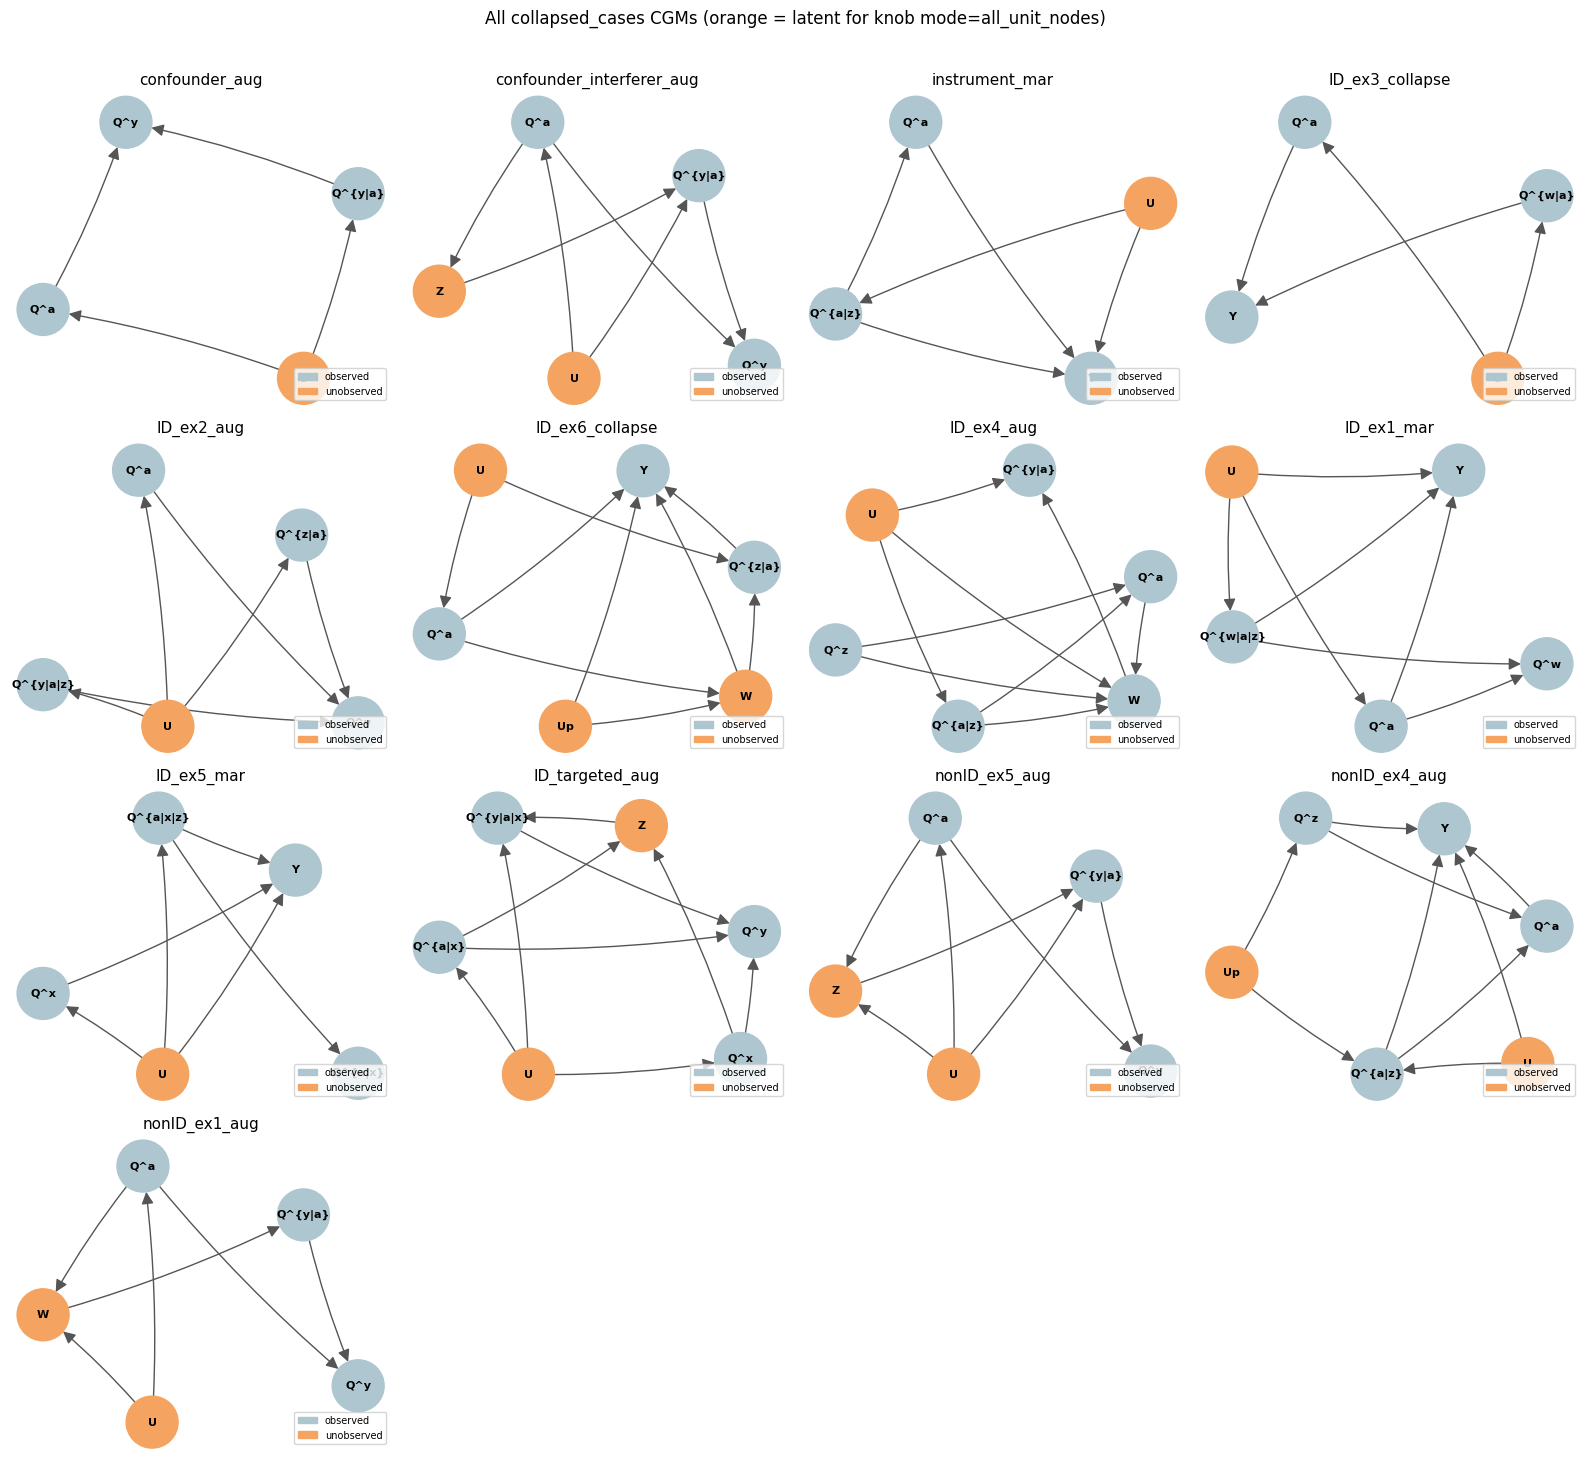

                             Y        X unobserved_mode  n_nodes  n_edges  dag_ok  expected_id  got_id (knob)  got_id (paper)  match_table  curated_truth  est_ok       ATE_hat  true_ATE  |ATE err| id_err est_err
case                                                                                                                                                                                                               
confounder_aug             Q^y      Q^a  all_unit_nodes        4        4    True         True           True            True         True           True    True  3.388156e-01  0.315249   0.023567               
confounder_interferer_aug  Q^y      Q^a  all_unit_nodes        5        6    True         True           True            True         True           True    True  2.174127e-01  0.379954   0.162542               
instrument_mar               Y      Q^a  all_unit_nodes        4        5    True         True           True            True         True           Tru

In [22]:
import copy
import math

import pandas as pd

GALLERY_UNOBSERVED_MODE = "all_unit_nodes"
GALLERY_X_OVERRIDE_BY_CASE = None
GALLERY_N_MC = ESTIMATION_N_MC
GALLERY_SIM_NU = min(150, N_UNITS)
GALLERY_SIM_NS = min(80, N_SUB)
GALLERY_SIM_SIZES = [GALLERY_SIM_NS] * GALLERY_SIM_NU
GALLERY_MC_TRUTH_NU = 4000
GALLERY_MC_TRUTH_NS = min(80, N_SUB)
rng_gallery = np.random.default_rng(12345)
rng_mc_truth = np.random.default_rng(99991)


def _gallery_unobserved_set(case, cgm, mode, y_node, x_node):
    unit_nodes = case[3]
    if mode == "all_unit_nodes":
        base = set(unit_nodes) & set(cgm.dag.nodes)
        return base - {y_node, x_node}
    if mode == "case_default":
        return set(case[9]) & set(cgm.dag.nodes)
    raise ValueError("unknown GALLERY_UNOBSERVED_MODE: {!r}".format(mode))


def _gallery_x_for_case(case):
    cname = case[0]
    if GALLERY_X_OVERRIDE_BY_CASE and cname in GALLERY_X_OVERRIDE_BY_CASE:
        return GALLERY_X_OVERRIDE_BY_CASE[cname]
    return case[8]


def simulate_binary_hscm(hscm, n_units, n_sub, rng):
    """we generate a coherent binary plate sample for any HSCMParametric DAG (§4 generic graphs)."""
    G = nx.DiGraph()
    G.add_nodes_from(hscm.nodes)
    G.add_edges_from(hscm.edges)
    order = list(nx.topological_sort(G))
    stor = {}
    for n in order:
        parents = [p for p, c in hscm.edges if c == n]
        is_sub = n in hscm.subunit_nodes
        if is_sub:
            if not parents:
                p = rng.uniform(0.25, 0.75, size=(n_units, n_sub))
                arr = rng.binomial(1, p).astype(float)
            else:
                acc = np.zeros((n_units, n_sub), dtype=float)
                for p in parents:
                    if p in hscm.subunit_nodes:
                        acc += 0.75 * stor[p]
                    else:
                        acc += 0.75 * stor[p][:, None]
                prob = np.clip(sigmoid(acc - 0.2), 0.02, 0.98)
                arr = rng.binomial(1, prob).astype(float)
        else:
            if not parents:
                p = rng.uniform(0.25, 0.75, size=n_units)
                arr = rng.binomial(1, p).astype(float)
            else:
                acc = np.zeros(n_units, dtype=float)
                for p in parents:
                    if p in hscm.subunit_nodes:
                        acc += 0.75 * stor[p].mean(axis=1)
                    else:
                        acc += 0.75 * stor[p]
                prob = np.clip(sigmoid(acc - 0.2), 0.02, 0.98)
                arr = rng.binomial(1, prob).astype(float)
        stor[n] = arr
    return {n.lstrip("_"): stor[n] for n in stor}


def _bern_families(data_dict):
    return {k: "bernoulli" for k in data_dict}


def _gallery_x_to_forced_subunits(x_node, subunit_nodes):
    s = (x_node or "").strip()
    if s == "Q^a":
        return ["A"] if "A" in subunit_nodes else []
    if s == "Q^w":
        return ["W"] if "W" in subunit_nodes else []
    if s == "Q^{a|x}":
        out = []
        if "A" in subunit_nodes:
            out.append("A")
        if "X" in subunit_nodes:
            out.append("X")
        return out
    if s == "Q^z":
        return ["Z"] if "Z" in subunit_nodes else []
    raise ValueError("unknown gallery x_node for structural do(): {!r}".format(x_node))


def _gallery_outcome_per_unit(stor, y_node, unit_nodes, subunit_nodes):
    if y_node == "Q^y":
        y_arr = stor["Y"]
        if y_arr.ndim == 2:
            return y_arr.mean(axis=1).astype(float)
        return y_arr.astype(float).ravel()
    if y_node in unit_nodes:
        return np.asarray(stor[y_node], dtype=float).ravel()
    if y_node in subunit_nodes:
        v = stor[y_node]
        if v.ndim == 2:
            return v.mean(axis=1).astype(float)
        return v.astype(float).ravel()
    raise ValueError("gallery outcome y_node={!r}".format(y_node))


def simulate_binary_hscm_do(nodes, edges, unit_nodes, subunit_nodes, n_units, n_sub, rng, forced_subunits):
    """we same SCM as simulate_binary_hscm but pin listed subunit plates (structural do)."""
    g = nx.DiGraph()
    g.add_nodes_from(nodes)
    g.add_edges_from(edges)
    order = list(nx.topological_sort(g))
    stor = {}
    forced = {k: float(v) for k, v in forced_subunits.items()}
    for n in order:
        if n in forced:
            v = forced[n]
            if n in subunit_nodes:
                stor[n] = np.full((n_units, n_sub), v, dtype=float)
            else:
                stor[n] = np.full(n_units, v, dtype=float)
            continue
        parents = [p for p, c in edges if c == n]
        is_sub = n in subunit_nodes
        if is_sub:
            if not parents:
                p = rng.uniform(0.25, 0.75, size=(n_units, n_sub))
                arr = rng.binomial(1, p).astype(float)
            else:
                acc = np.zeros((n_units, n_sub), dtype=float)
                for p in parents:
                    if p in subunit_nodes:
                        acc += 0.75 * stor[p]
                    else:
                        acc += 0.75 * stor[p][:, None]
                prob = np.clip(sigmoid(acc - 0.2), 0.02, 0.98)
                arr = rng.binomial(1, prob).astype(float)
        else:
            if not parents:
                p = rng.uniform(0.25, 0.75, size=n_units)
                arr = rng.binomial(1, p).astype(float)
            else:
                acc = np.zeros(n_units, dtype=float)
                for p in parents:
                    if p in subunit_nodes:
                        acc += 0.75 * stor[p].mean(axis=1)
                    else:
                        acc += 0.75 * stor[p]
                prob = np.clip(sigmoid(acc - 0.2), 0.02, 0.98)
                arr = rng.binomial(1, prob).astype(float)
        stor[n] = arr
    return {k.lstrip("_"): v for k, v in stor.items()}


def mc_truth_ate_binary_plate(case, x_node, n_units, n_sub, rng):
    """we E[outcome|do(X)=1] - E[outcome|do(X)=0] for the case HSCM (same generator as simulate_binary_hscm)."""
    nodes, edges, unit_nodes, subunit_nodes = case[1], case[2], case[3], case[4]
    y_node = case[7]
    targets = _gallery_x_to_forced_subunits(x_node, subunit_nodes)
    if not targets:
        return float("nan")
    f1 = {t: 1.0 for t in targets}
    f0 = {t: 0.0 for t in targets}
    stor1 = simulate_binary_hscm_do(nodes, edges, unit_nodes, subunit_nodes, n_units, n_sub, rng, f1)
    stor0 = simulate_binary_hscm_do(nodes, edges, unit_nodes, subunit_nodes, n_units, n_sub, rng, f0)
    y1 = _gallery_outcome_per_unit(stor1, y_node, unit_nodes, subunit_nodes)
    y0 = _gallery_outcome_per_unit(stor0, y_node, unit_nodes, subunit_nodes)
    return float(y1.mean() - y0.mean())


CURATED_CASE_DATA = {
    "confounder_aug": {
        "data": {"A": A_conf, "Y": Y_conf},
        "truth_ate": true_ate_conf,
        "truth_e1": true_ey1_conf,
        "truth_e0": true_ey0_conf,
    },
    "confounder_interferer_aug": {
        "data": {"A": A_ci, "Y": Y_ci, "Z": Z_ci},
        "truth_ate": true_ate_ci,
        "truth_e1": true_ey1_ci,
        "truth_e0": true_ey0_ci,
    },
    "instrument_mar": {
        "data": {"Y": Y_inst, "A": A_inst, "Z": Z_inst},
        "truth_ate": true_ate_inst,
        "truth_e1": true_ey1_inst,
        "truth_e0": true_ey0_inst,
    },
}

gallery_rows = []
cases = list(COLLAPSED_DO_CALCULUS_CASES)
nc = len(cases)
ncols = 4
nrows = int(math.ceil(nc / float(ncols)))

fig_gal, axes_gal = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.6 * nrows))
axes_flat = np.atleast_1d(axes_gal).ravel()

for idx, case in enumerate(cases):
    cname = case[0]
    y_node = case[7]
    expected_id = case[10]
    cgm, _u_default, _y_def, _x_def, _exp = build_cgm_for_case(dc_pkg, case)
    x_node = _gallery_x_for_case(case)
    unobs = _gallery_unobserved_set(case, cgm, GALLERY_UNOBSERVED_MODE, y_node, x_node)

    dag_ok = nx.is_directed_acyclic_graph(cgm.dag)
    cgm_plot = copy.deepcopy(cgm)
    cgm_plot.unobserved_variables = set(unobs)

    ax = axes_flat[idx]
    plot_cgm(cgm_plot, cname, ax, highlight_unobs=unobs)

    if cname in CURATED_CASE_DATA:
        data_obs = CURATED_CASE_DATA[cname]["data"]
        truth_ate = CURATED_CASE_DATA[cname]["truth_ate"]
        has_truth = True
    else:
        hscm_sim = HSCMParametric(
            nodes=set(case[1]),
            edges=set(case[2]),
            unit_nodes=set(case[3]),
            subunit_nodes=set(case[4]),
            sizes=GALLERY_SIM_SIZES,
            node_functions={n: _noop for n in case[1]},
            data={},
        )
        data_obs = simulate_binary_hscm(hscm_sim, GALLERY_SIM_NU, GALLERY_SIM_NS, rng_gallery)
        truth_ate = mc_truth_ate_binary_plate(
            case,
            x_node,
            GALLERY_MC_TRUTH_NU,
            GALLERY_MC_TRUTH_NS,
            rng_mc_truth,
        )
        has_truth = np.isfinite(truth_ate)

    got_knob = False
    got_paper = False
    err_id = ""
    res_paper = None
    if not PYAGNUM_AVAILABLE:
        err_id = "pyagrum not installed"
    else:
        res_knob = identify_effect(cgm, Y=y_node, X=x_node, unobserved=unobs)
        got_knob = bool(res_knob.identifiable)
        err_id = (res_knob.error or "")[:120]
        unobs_paper = set(case[9]) & set(cgm.dag.nodes)
        res_paper = identify_effect(cgm, Y=y_node, X=x_node, unobserved=unobs_paper)
        got_paper = bool(res_paper.identifiable)

    id_match_paper = got_paper == expected_id
    ate_hat = float("nan")
    est_ok = False
    est_msg = ""
    abs_err = float("nan")
    if PYAGNUM_AVAILABLE and got_paper and res_paper is not None:
        fam = _bern_families(data_obs)
        try:
            e1 = estimate_causal_effect(
                res_paper,
                data=data_obs,
                intervention={x_node: 1.0},
                distribution_families=fam,
                random_seed=0,
                n_mc_samples=GALLERY_N_MC,
            )
            e0 = estimate_causal_effect(
                res_paper,
                data=data_obs,
                intervention={x_node: 0.0},
                distribution_families=fam,
                random_seed=1,
                n_mc_samples=GALLERY_N_MC,
            )
            ate_hat = float(e1 - e0)
            est_ok = True
            if has_truth and np.isfinite(truth_ate) and np.isfinite(ate_hat):
                abs_err = abs(ate_hat - truth_ate)
        except Exception as ex:
            est_msg = str(ex)[:200]

    gallery_rows.append(
        {
            "case": cname,
            "Y": y_node,
            "X": x_node,
            "unobserved_mode": GALLERY_UNOBSERVED_MODE,
            "n_nodes": len(cgm.dag.nodes),
            "n_edges": len(cgm.dag.edges),
            "dag_ok": dag_ok,
            "expected_id": expected_id,
            "got_id (knob)": got_knob,
            "got_id (paper)": got_paper,
            "match_table": id_match_paper,
            "curated_truth": cname in CURATED_CASE_DATA,
            "est_ok": est_ok,
            "ATE_hat": ate_hat,
            "true_ATE": truth_ate if has_truth else float("nan"),
            "|ATE err|": abs_err,
            "id_err": err_id if not got_knob else "",
            "est_err": est_msg,
        }
    )

for j in range(nc, len(axes_flat)):
    axes_flat[j].axis("off")

plt.suptitle(
    "All collapsed_cases CGMs (orange = latent for knob mode={})".format(GALLERY_UNOBSERVED_MODE),
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.show()

df_gallery = pd.DataFrame(gallery_rows).set_index("case")
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 40)
print(df_gallery.to_string())

n_dag_fail = int((~df_gallery["dag_ok"]).sum())
n_id_mismatch = int((~df_gallery["match_table"]).sum())
n_est_fail = int((df_gallery["got_id (paper)"] & ~df_gallery["est_ok"]).sum())
print(
    "\n§4 summary: DAG_fail={}, ID_table_mismatch={}, identifiable_but_est_failed={}".format(
        n_dag_fail,
        n_id_mismatch,
        n_est_fail,
    )
)
cur = df_gallery[df_gallery["curated_truth"]]
if len(cur):
    print("\nCurated cases (§1–3 DGP truth):")
    print(cur[["got_id (paper)", "est_ok", "ATE_hat", "true_ATE", "|ATE err|"]].to_string())
if n_dag_fail or n_id_mismatch:
    print("\nwe inspect ID/DAG failures:")
    print(df_gallery.loc[~df_gallery["dag_ok"] | ~df_gallery["match_table"]])
if n_est_fail:
    print("\nEstimation failures (paper-ID True):")
    print(df_gallery.loc[df_gallery["got_id (paper)"] & ~df_gallery["est_ok"]][["est_err"]])

---
## 5 — Summary (three DGP models, same numbers as §4 curated rows)

Table and bars use **`df_gallery`** from §4: curated rows use §1–3 truth; other rows use structural MC `true_ATE` vs `ATE_hat` on the same plate SCM.

In [23]:
_CURATED_LABELS = [
    ("confounder_aug", "CONFOUNDER", effect_conf, true_ate_conf),
    ("confounder_interferer_aug", "C&I", effect_ci, true_ate_ci),
    ("instrument_mar", "INSTRUMENT", effect_inst, true_ate_inst),
]
rows = []
for case_key, label, _legacy_est, _legacy_true in _CURATED_LABELS:
    r = df_gallery.loc[case_key]
    ate_hat = float(r["ATE_hat"]) if r["est_ok"] else float("nan")
    ttrue = float(r["true_ATE"])
    rows.append(
        {
            "Model": label,
            "True ATE": round(ttrue, 4),
            "Est §1–3": round(_legacy_est, 4),
            "Est §4 gallery": round(ate_hat, 4) if np.isfinite(ate_hat) else None,
            "|§4−truth|": round(abs(ate_hat - ttrue), 4) if r["est_ok"] and np.isfinite(ate_hat) else None,
        }
    )

df = pd.DataFrame(rows).set_index("Model")
print(df.to_string())

            True ATE  Est §1–3  Est §4 gallery  |§4−truth|
Model                                                     
CONFOUNDER    0.3152    0.3388          0.3388      0.0236
C&I           0.3800    0.2173          0.2174      0.1625
INSTRUMENT    0.5756    0.7277          0.7279      0.1523


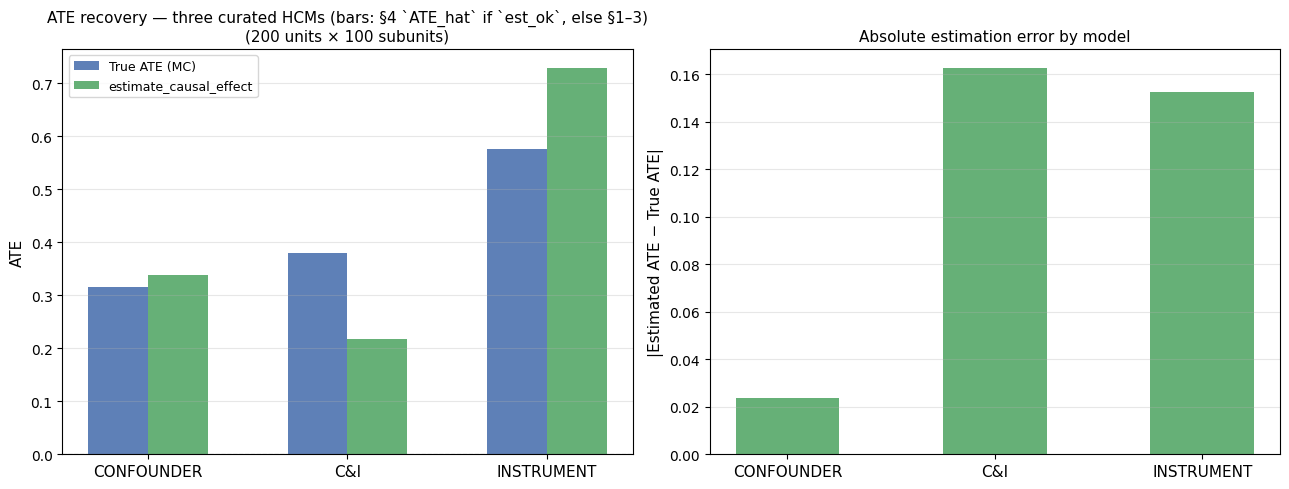

In [24]:
models    = [t[1] for t in _CURATED_LABELS]
true_ates = [float(df_gallery.loc[t[0]]["true_ATE"]) for t in _CURATED_LABELS]
est_ates  = [
    float(df_gallery.loc[t[0]]["ATE_hat"])
    if df_gallery.loc[t[0]]["est_ok"]
    else t[2]
    for t in _CURATED_LABELS
]

x, w = np.arange(len(models)), 0.3

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ATE comparison
ax = axes[0]
ax.bar(x - w/2, true_ates, w, label='True ATE (MC)',          color='#4c72b0', alpha=0.9)
ax.bar(x + w/2, est_ates,  w, label='estimate_causal_effect',  color='#55a868', alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('ATE', fontsize=11)
ax.set_title(
    "ATE recovery — three curated HCMs (bars: §4 `ATE_hat` if `est_ok`, else §1–3)\n"
    "({} units × {} subunits)".format(N_UNITS, N_SUB),
    fontsize=11,
)
ax.legend(fontsize=9); ax.axhline(0, color='gray', lw=0.8, ls='--'); ax.grid(axis='y', alpha=0.3)

# Absolute errors
ax2 = axes[1]
errs = [abs(e - t) for e, t in zip(est_ates, true_ates)]
ax2.bar(x, errs, 0.5, color='#55a868', alpha=0.9)
ax2.set_xticks(x); ax2.set_xticklabels(models, fontsize=11)
ax2.set_ylabel('|Estimated ATE − True ATE|', fontsize=11)
ax2.set_title('Absolute estimation error by model', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()